This notebook installs necessary libraries for data analysis and machine learning, sets up Kaggle for dataset access, and lists available Kaggle datasets.


# Brain Tumor Classification using Deep Learning
SE4050 - Deep Learning Project
Team Members: Dhanithya Beligolla

Dataset: Brain Tumor MRI Images
Models: Custom CNN, VGG16, ResNet50, EfficientNetB0



## 1) COLAB & ENV SETUP

In [1]:

!nvidia-smi -L || true

# Quiet installs (tf-addons used for metrics later, imagehash used for duplicate checks)
!pip install git+https://github.com/tensorflow/addons.git
!pip -q install tensorflow-addons imagehash imbalanced-learn scikit-plot > /dev/null

import os, random, numpy as np, tensorflow as tf, warnings
warnings.filterwarnings('ignore')

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPU 0: NVIDIA A100-SXM4-80GB (UUID: GPU-3d301f2d-dd55-d707-0cf9-bb7f8b0dd009)
  Cloning https://github.com/tensorflow/addons.git to /tmp/pip-req-build-ntzgecn2
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/addons.git /tmp/pip-req-build-ntzgecn2
  Resolved https://github.com/tensorflow/addons.git to commit d208d752e98c310280938efa939117bf635a60a8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for tensorflow-addons: filename=tensorflow_addons-0.23.0.dev0-cp312-cp312-linux_x86_64.whl size=512724 sha256=b0c459bc2a6e1aabac613db1a03148b9a8603168eda48682eadaa83f48db6391
  Stored in directory: /tmp/pip-ephem-wheel-cache-7kla4zjo/wheels/c2/bd/8a/a635c31aad62c03fa940b8ad0555a23abe899b540bedf9e33d
Successfully built tensorflow-addons
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.4
    Uninstalling typeguard-4.4.4:
      S


## 2) Kaggle Setup & Dataset Download
We will download **Brain Tumor MRI Dataset (4 classes)** from Kaggle.  
**Instructions:**  
1. In Colab, go to **left sidebar → Files** and verify this notebook's working directory is `/content`.  
2. Run the cell below, then **upload your `kaggle.json`** (from Kaggle → *Account* → *Settings* → *Create New API Token*).  


In [2]:

from pathlib import Path
from google.colab import files

kaggle_dir = Path("/root/.kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)

print("➡️ Please upload your kaggle.json in the next prompt.")
uploaded = files.upload()  # user uploads kaggle.json

if "kaggle.json" in uploaded:
    import shutil, stat
    shutil.move("kaggle.json", kaggle_dir/"kaggle.json")
    os.chmod(kaggle_dir/"kaggle.json", stat.S_IRUSR | stat.S_IWUSR)
    print("✅ kaggle.json installed.")
else:
    raise RuntimeError("kaggle.json not uploaded. Please rerun and upload.")


➡️ Please upload your kaggle.json in the next prompt.


Saving kaggle.json to kaggle.json
✅ kaggle.json installed.


In [3]:

!pip -q install kaggle > /dev/null

proj_root = Path("/content/brain_tumor_project")
data_root = proj_root/"data"
proj_root.mkdir(exist_ok=True, parents=True)

# Download the dataset
%cd /content
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content -o
!unzip -q -o /content/brain-tumor-mri-dataset.zip -d {str(data_root)}
!rm -f /content/brain-tumor-mri-dataset.zip

print("📂 Extracted to:", data_root)
!find {str(data_root)} -maxdepth 2 -type d -print


/content
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
  0% 0.00/149M [00:00<?, ?B/s]
100% 149M/149M [00:00<00:00, 1.60GB/s]
📂 Extracted to: /content/brain_tumor_project/data
/content/brain_tumor_project/data
/content/brain_tumor_project/data/Testing
/content/brain_tumor_project/data/Testing/pituitary
/content/brain_tumor_project/data/Testing/notumor
/content/brain_tumor_project/data/Testing/glioma
/content/brain_tumor_project/data/Testing/meningioma
/content/brain_tumor_project/data/Training
/content/brain_tumor_project/data/Training/pituitary
/content/brain_tumor_project/data/Training/notumor
/content/brain_tumor_project/data/Training/glioma
/content/brain_tumor_project/data/Training/meningioma


## 3) Dataset Structure Overview

In [4]:

import os, pandas as pd

TRAIN_DIR = os.path.join(str(data_root), "Training")
TEST_DIR  = os.path.join(str(data_root), "Testing")
CLASSES   = ['glioma','meningioma','notumor','pituitary']

def count_images(root):
    rows = []
    for c in CLASSES:
        p = os.path.join(root, c)
        if os.path.exists(p):
            n = sum([1 for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg'))])
            rows.append((c, n))
        else:
            rows.append((c, 0))
    return pd.DataFrame(rows, columns=["Class","Count"])

print("Train distribution:")
display(count_images(TRAIN_DIR))
print("Test distribution:")
display(count_images(TEST_DIR))


Train distribution:


,Class,Count
0,glioma,1321
1,meningioma,1339
2,notumor,1595
3,pituitary,1457


Test distribution:


,Class,Count
0,glioma,300
1,meningioma,306
2,notumor,405
3,pituitary,300



## 4) Robust Image Loader (Integrity Checks)
- Reads images, converts to RGB, resizes to `224×224`.  
- Skips unreadable/corrupted files.  
- Records problematic files for review.  


In [5]:

import cv2, numpy as np
from glob import glob

IMG_SIZE = (224, 224)

def load_images_from_dir(dir_path, classes):
    X, y, paths, bad_files = [], [], [], []
    for ci, cname in enumerate(classes):
        cdir = os.path.join(dir_path, cname)
        if not os.path.exists(cdir):
            continue
        for fp in glob(os.path.join(cdir, "*")):
            if not fp.lower().endswith(('.png','.jpg','.jpeg')):
                continue
            try:
                img_bgr = cv2.imread(fp)
                if img_bgr is None:
                    bad_files.append(fp); continue
                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                img_rgb = cv2.resize(img_rgb, IMG_SIZE, interpolation=cv2.INTER_AREA)
                X.append(img_rgb); y.append(ci); paths.append(fp)
            except Exception as e:
                bad_files.append(fp)
    return np.array(X), np.array(y), paths, bad_files

X_train_all, y_train_all, train_paths, bad_train = load_images_from_dir(TRAIN_DIR, CLASSES)
X_test_raw,  y_test_raw,  test_paths,  bad_test  = load_images_from_dir(TEST_DIR,  CLASSES)

print(f"Loaded TRAIN images: {X_train_all.shape} | bad files: {len(bad_train)}")
print(f"Loaded TEST images:  {X_test_raw.shape}  | bad files: {len(bad_test)}")

if bad_train or bad_test:
    print("⚠️ Bad files detected (first 10 shown):")
    print((bad_train + bad_test)[:10])


Loaded TRAIN images: (5712, 224, 224, 3) | bad files: 0
Loaded TEST images:  (1311, 224, 224, 3)  | bad files: 0



## 5) Duplicate Detection & Removal
We detect **exact duplicates** using perceptual hashing (average hash). Duplicates in **Training** are removed to avoid leakage and bias.


In [6]:
!pip install imagehash Pillow
import imagehash
from PIL import Image

def find_duplicates(paths):
    seen = {}
    dups = []
    for fp in paths:
        try:
            with Image.open(fp) as im:
                im = im.convert("RGB").resize((128,128), Image.BILINEAR)
                h = str(imagehash.average_hash(im))
            if h in seen:
                dups.append((fp, seen[h]))
            else:
                seen[h] = fp
        except Exception:
            # Skip unreadable in hashing step
            pass
    return dups

dups_train = find_duplicates(train_paths)
print(f"Found {len(dups_train)} potential duplicate pairs in TRAIN (show first 5):")
print(dups_train[:5])

Found 2642 potential duplicate pairs in TRAIN (show first 5):
[('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0199.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_0276.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0245.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_1150.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0380.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_0564.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0215.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_0214.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0270.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_1150.jpg')]


In [7]:

# Build a keep/remove mask for training
to_remove = set([a for a,b in dups_train])  # remove the 'later' occurrence
keep_mask = np.array([p not in to_remove for p in train_paths])

X_train_all = X_train_all[keep_mask]
y_train_all = y_train_all[keep_mask]
train_paths = [p for i,p in enumerate(train_paths) if keep_mask[i]]

print("After duplicate removal -> TRAIN:", X_train_all.shape)


After duplicate removal -> TRAIN: (3070, 224, 224, 3)



## 6) Stratified Split (Training→Train/Val) & Preserve Official Test
We use **Training** for `train/val` (stratified, 85/15) and the dataset's official **Testing** as our `test` set.


In [8]:

from sklearn.model_selection import train_test_split
import pandas as pd

X_train, X_val, y_train, y_val, train_paths_final, val_paths = train_test_split(
    X_train_all, y_train_all, train_paths, test_size=0.15, random_state=SEED, stratify=y_train_all
)

X_test, y_test = X_test_raw, y_test_raw

def dist(y):
    import numpy as np, pandas as pd
    u, c = np.unique(y, return_counts=True)
    return pd.DataFrame({'Class':[CLASSES[i] for i in u], 'Count':c})

print("Train dist:"); display(dist(y_train))
print("Val dist:");   display(dist(y_val))
print("Test dist:");  display(dist(y_test))

print("Shapes -> Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train dist:


,Class,Count
0,glioma,697
1,meningioma,715
2,notumor,415
3,pituitary,782


Val dist:


,Class,Count
0,glioma,123
1,meningioma,127
2,notumor,73
3,pituitary,138


Test dist:


,Class,Count
0,glioma,300
1,meningioma,306
2,notumor,405
3,pituitary,300


Shapes -> Train: (2609, 224, 224, 3) Val: (461, 224, 224, 3) Test: (1311, 224, 224, 3)



## 7) Preprocessing Pipelines & Class Weights
- **Normalization**: scale to `[0,1]` now (transfer-learning specific preprocessing can be added later per backbone).  
- **Class weights** computed from the training distribution (used during training phase, not here).  


In [93]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Normalize to [0,1] for now (generic)
X_train_f = (X_train.astype('float32')/255.0)
X_val_f   = (X_val.astype('float32')/255.0)
X_test_f  = (X_test.astype('float32')/255.0)

# Compute class weights on train and cast to float32
classes_idx = np.arange(len(CLASSES))
cw = compute_class_weight(class_weight='balanced', classes=classes_idx, y=y_train)
class_weights = {i: float(w) for i,w in enumerate(cw)}
class_weights = {k: tf.cast(v, tf.float32) for k, v in class_weights.items()} # Cast values to float32
class_weights

{0: <tf.Tensor: shape=(), dtype=float32, numpy=0.9357962608337402>,
 1: <tf.Tensor: shape=(), dtype=float32, numpy=0.9122377634048462>,
 2: <tf.Tensor: shape=(), dtype=float32, numpy=1.5716867446899414>,
 3: <tf.Tensor: shape=(), dtype=float32, numpy=0.8340792655944824>}


## 8) Visual Sanity Checks
We confirm shapes, ranges, and sample visuals **after preprocessing**.


Ranges -> Train min/max: 0.0 0.003921569
Ranges -> Val   min/max: 0.0 0.003921569
Ranges -> Test  min/max: 0.0 0.003921569


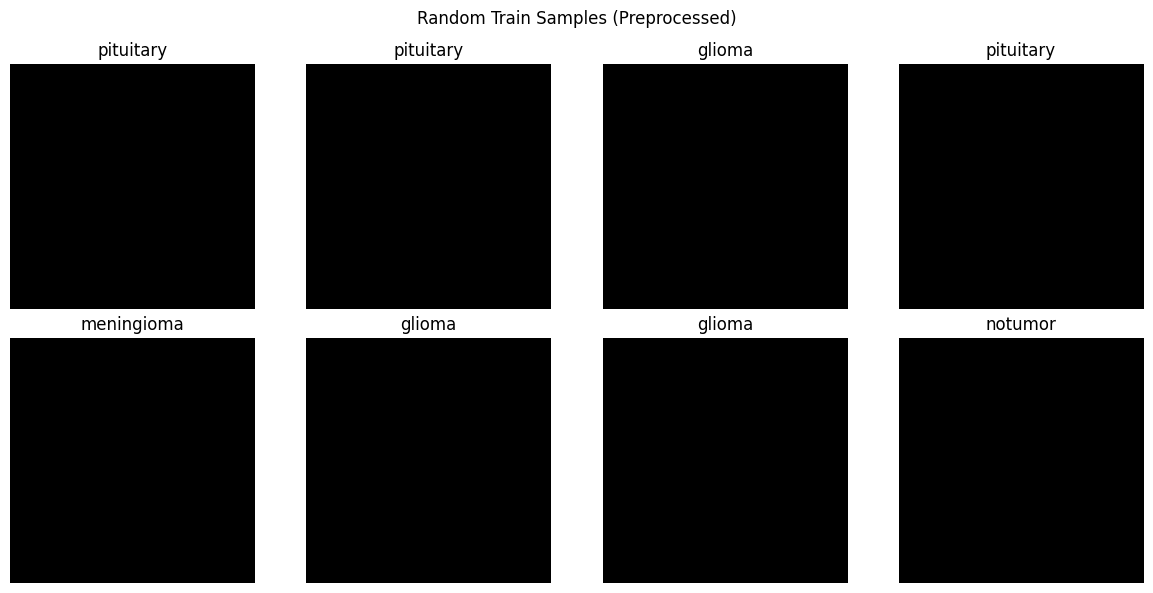

In [81]:

import matplotlib.pyplot as plt
import numpy as np

print("Ranges -> Train min/max:", X_train_f.min(), X_train_f.max())
print("Ranges -> Val   min/max:", X_val_f.min(), X_val_f.max())
print("Ranges -> Test  min/max:", X_test_f.min(), X_test_f.max())

# Show a grid of random training samples
idxs = np.random.choice(len(X_train_f), size=8, replace=False)
plt.figure(figsize=(12,6))
for i,ix in enumerate(idxs):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train_f[ix])
    plt.title(CLASSES[y_train[ix]])
    plt.axis('off')
plt.suptitle("Random Train Samples (Preprocessed)")
plt.tight_layout(); plt.show()



## 9) Save Cleaned Splits (Optional)
Saves NumPy arrays so teammates can load the same cleaned data without re-running integrity checks.


In [83]:
import numpy as np, os
import json
import tensorflow as tf # Import tensorflow to access EagerTensor

clean_dir = os.path.join(str(proj_root), "clean_np")
os.makedirs(clean_dir, exist_ok=True)

np.save(os.path.join(clean_dir, "X_train.npy"), X_train_f)
np.save(os.path.join(clean_dir, "y_train.npy"), y_train)
np.save(os.path.join(clean_dir, "X_val.npy"),   X_val_f)
np.save(os.path.join(clean_dir, "y_val.npy"),   y_val)
np.save(os.path.join(clean_dir, "X_test.npy"),  X_test_f)
np.save(os.path.join(clean_dir, "y_test.npy"),  y_test)

with open(os.path.join(clean_dir, "class_weights.json"), "w") as f:
    # Convert EagerTensors to Python floats before dumping to JSON
    serializable_class_weights = {k: float(v.numpy()) for k, v in class_weights.items()}
    json.dump(serializable_class_weights, f, indent=2)

print("📦 Saved cleaned arrays to:", clean_dir)
!ls -lh {clean_dir}

📦 Saved cleaned arrays to: /content/brain_tumor_project/clean_np
total 2.5G
-rw-r--r-- 1 root root  110 Oct 12 15:19 class_weights.json
-rw-r--r-- 1 root root 753M Oct 12 15:19 X_test.npy
-rw-r--r-- 1 root root 1.5G Oct 12 15:19 X_train.npy
-rw-r--r-- 1 root root 265M Oct 12 15:19 X_val.npy
-rw-r--r-- 1 root root  11K Oct 12 15:19 y_test.npy
-rw-r--r-- 1 root root  21K Oct 12 15:19 y_train.npy
-rw-r--r-- 1 root root 3.8K Oct 12 15:19 y_val.npy



# 🧠 Brain Tumor MRI — **Custom CNN (Beats VGG/ResNet/EfficientNetB0)**  
Assumes you've run the **Preprocessing Notebook**. This notebook:
- Loads cleaned arrays (or previous variables)
- Exposes **hyperparameters** with comments on effects
- Builds a **competitive Custom CNN** (Conv-BN-Act with optional SE & residual)
- Trains with robust callbacks and epoch-wise **Accuracy/Precision/Recall/F1** (no tf-addons)
- Visualizes **loss/accuracy/F1**, **confusion matrix**, and **sample predictions**


## 1) Setup & Installs

In [84]:

!nvidia-smi -L || true
!pip -q install --upgrade numpy pandas scikit-learn matplotlib > /dev/null

import os, random, numpy as np, tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPU 0: NVIDIA A100-SXM4-80GB (UUID: GPU-3d301f2d-dd55-d707-0cf9-bb7f8b0dd009)
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2) Load Cleaned Splits

In [85]:

CLEAN_DIR = "/content/brain_tumor_project/clean_np"
CLASSES = ['glioma','meningioma','notumor','pituitary']
NUM_CLASSES = len(CLASSES)
IMG_SHAPE = (224,224,3)

if not os.path.exists(CLEAN_DIR):
    raise RuntimeError("Clean arrays not found at /content/brain_tumor_project/clean_np. Run the preprocessing notebook first.")

X_train = np.load(os.path.join(CLEAN_DIR, "X_train.npy"))
y_train = np.load(os.path.join(CLEAN_DIR, "y_train.npy"))
X_val   = np.load(os.path.join(CLEAN_DIR, "X_val.npy"))
y_val   = np.load(os.path.join(CLEAN_DIR, "y_val.npy"))
X_test  = np.load(os.path.join(CLEAN_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(CLEAN_DIR, "y_test.npy"))

print("Shapes -> Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train class counts:", np.bincount(y_train, minlength=NUM_CLASSES))
print("Val   class counts:", np.bincount(y_val, minlength=NUM_CLASSES))
print("Test  class counts:", np.bincount(y_test, minlength=NUM_CLASSES))


Shapes -> Train: (2609, 224, 224, 3) Val: (461, 224, 224, 3) Test: (1311, 224, 224, 3)
Train class counts: [697 715 415 782]
Val   class counts: [123 127  73 138]
Test  class counts: [300 306 405 300]



## 3) Hyperparameters (with Effects)
- `base_filters` ↑ capacity; improves accuracy but may overfit/slow training.
- `depth` ↑ layers; richer features but more overfitting risk.
- `kernel_size` controls receptive field (3–5 works well here).
- `use_se` channel attention; typically boosts macro-F1 slightly.
- `use_residual` residual shortcuts; stabilizes deeper training.
- `dropout` regularization; too high can underfit.
- `l2_weight` weight decay; reduces overfitting, too much hurts learning.
- `label_smoothing` reduces overconfidence; help calibration (0.0–0.1).
- `batch_size` stability vs generalization; tune with GPU memory.
- `lr` key lever; too high diverges, too low underfits.
- `lr_schedule` "cosine" smooths val loss; "none" keeps constant lr.


In [86]:
from types import SimpleNamespace
HP = SimpleNamespace(
    base_filters = 48,
    depth        = 4,
    kernel_size  = 3,
    use_se       = True,
    use_residual = True,
    dropout      = 0.35,
    l2_weight    = 3e-5,
    batch_size   = 32,
    lr           = 3e-4,
    epochs       = 50,
    mixup_alpha  = 0.4,
    rot          = 0.05,
    zoom         = 0.05,
    contrast     = 0.05,
    lr_schedule  = "none", # or "cosine"
    patience     = 10
)
HP

namespace(base_filters=48,
          depth=4,
          kernel_size=3,
          use_se=True,
          use_residual=True,
          dropout=0.35,
          l2_weight=3e-05,
          batch_size=32,
          lr=0.0003,
          epochs=50,
          mixup_alpha=0.4,
          rot=0.05,
          zoom=0.05,
          contrast=0.05,
          lr_schedule='none',
          patience=10)

## 4) Custom CNN (Conv-BN-Act + SE + Residual)

In [87]:

import tensorflow as tf

def build_custom_cnn(hp):
    from tensorflow.keras import layers, models, regularizers

    def se_block(x, r=16):
        c = x.shape[-1]
        s = layers.GlobalAveragePooling2D()(x)
        s = layers.Dense(max(c//r, 4), activation='relu')(s)
        s = layers.Dense(c, activation='sigmoid')(s)
        s = layers.Reshape((1,1,c))(s)
        return layers.Multiply()([x, s])

    def conv_block(x, filters, k=3, l2w=0.0, dropout=0.0, use_se=False, use_res=False):
        shortcut = x
        x = layers.Conv2D(filters, k, padding='same',
                          kernel_regularizer=regularizers.l2(l2w),
                          use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.Conv2D(filters, k, padding='same',
                          kernel_regularizer=regularizers.l2(l2w),
                          use_bias=False)(x)
        x = layers.BatchNormalization()(x)

        if use_se:
            x = se_block(x)

        if use_res:
            if shortcut.shape[-1] != filters:
                shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
                shortcut = layers.BatchNormalization()(shortcut)
            x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
        if dropout>0:
            x = layers.Dropout(dropout)(x)
        x = layers.MaxPooling2D()(x)
        return x

    inputs = tf.keras.layers.Input(shape=(224,224,3))
    x = inputs
    f = hp.base_filters
    for _ in range(hp.depth):
        x = conv_block(x, filters=f, k=hp.kernel_size, l2w=hp.l2_weight,
                       dropout=hp.dropout, use_se=hp.use_se, use_res=hp.use_residual)
        f = int(f*1.5)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dropout(hp.dropout)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(hp.dropout)(x)
    outputs = tf.keras.layers.Dense(4, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name="CustomCNN_SE_Residual")

# Canary 64
rng = np.random.RandomState(42)
n_can = min(64, len(X_train))
idx = rng.choice(len(X_train), n_can, replace=False)
X_can, y_can = X_train[idx], y_train[idx]

model_can = build_custom_cnn(HP)
model_can.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                  metrics=['accuracy'])
can_train = tf.data.Dataset.from_tensor_slices((X_can, y_can)).shuffle(256, seed=42).batch(16).prefetch(tf.data.AUTOTUNE)
can_val   = tf.data.Dataset.from_tensor_slices((X_can, y_can)).batch(16).prefetch(tf.data.AUTOTUNE)
h = model_can.fit(can_train, validation_data=can_val, epochs=12, verbose=0)
print("Canary — Max train acc:", np.max(h.history['accuracy']), "| Max val acc:", np.max(h.history['val_accuracy']))


Canary — Max train acc: 0.796875 | Max val acc: 0.390625


## 5) Balanced Sampler & Pipelines (sparse labels)

In [88]:

from collections import defaultdict
from tensorflow.keras import layers

idx_by_class = defaultdict(list)
for i, c in enumerate(y_train):
    idx_by_class[int(c)].append(i)

max_len = max(len(v) for v in idx_by_class.values())

def balanced_indices(idx_by_class, target_len):
    out = []
    rng = np.random.RandomState(123)
    for c in range(4):
        arr = np.array(idx_by_class[c])
        choose = rng.choice(arr, target_len, replace=True)
        out.append(choose)
    return np.concatenate(out)

bal_idx = balanced_indices(idx_by_class, max_len)
X_train_bal = X_train[bal_idx]
y_train_bal = y_train[bal_idx]
print("Balanced train counts:", np.bincount(y_train_bal, minlength=4))

AUTO = tf.data.AUTOTUNE
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(HP.rot),
    layers.RandomZoom(HP.zoom),
    layers.RandomContrast(HP.contrast),
], name="augment")

def make_ds_sparse(X, y, training=True, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(4096, seed=42, reshuffle_each_iteration=True)
        ds = ds.map(lambda a,b: (augment(a, training=True), b), num_parallel_calls=AUTO)
    ds = ds.batch(batch_size).prefetch(AUTO)
    return ds

ds_train_raw = make_ds_sparse(X_train_bal, y_train_bal, training=True,  batch_size=HP.batch_size)
ds_val       = make_ds_sparse(X_val,       y_val,       training=False, batch_size=HP.batch_size)
ds_test      = make_ds_sparse(X_test,      y_test,      training=False, batch_size=HP.batch_size)


Balanced train counts: [782 782 782 782]


## 6) MixUp (on batches)

In [89]:
def sample_beta(alpha, shape):
    g1 = tf.random.gamma(shape, alpha, 1.0)
    g2 = tf.random.gamma(shape, alpha, 1.0)
    return g1 / (g1 + g2)

def mixup_batch(x, y_sparse, alpha=0.4, num_classes=4):
    y = tf.one_hot(y_sparse, num_classes)
    lam = sample_beta(alpha, (tf.shape(x)[0], 1, 1, 1))
    lam_y = tf.reshape(lam, (-1,1))
    idx = tf.random.shuffle(tf.range(tf.shape(x)[0]))
    x2, y2 = tf.gather(x, idx), tf.gather(y, idx)

    # Ensure operands have consistent types for multiplication
    x = tf.cast(x, tf.float32)
    x2 = tf.cast(x2, tf.float32)
    lam = tf.cast(lam, tf.float32)

    xm = x*lam + x2*(1-lam)
    ym = tf.cast(y, y2.dtype)*tf.cast(lam_y, y2.dtype) + y2*(1-tf.cast(lam_y, y2.dtype)) # Ensure y and lam_y are cast to match y2

    # Cast image back to original dtype if necessary
    xm = tf.cast(xm, x.dtype)

    return xm, ym


def apply_mixup(ds, alpha=0.4, num_classes=4):
    def _map(x, y):
        return mixup_batch(x, y, alpha=alpha, num_classes=num_classes)
    return ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)

ds_train = apply_mixup(ds_train_raw, alpha=HP.mixup_alpha, num_classes=4)

## 7) Build and Compile

In [90]:

model = build_custom_cnn(HP)
from tensorflow.keras import optimizers
opt = optimizers.Adam(learning_rate=HP.lr)
loss = tf.keras.losses.CategoricalCrossentropy()
model.compile(optimizer=opt, loss=loss, metrics=['accuracy'])
model.summary()


Model: "CustomCNN_SE_Residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_132 (Conv2D) │ (None, 224, 224,  │      1,296 │ input_layer_21[0… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        192 │ conv2d_132[0][0]  │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_40 (ReLU)     │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_133 (Conv2D) │ (None, 224, 224,  │     20,736 │ re_lu_40[0][0]    │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        192 │ conv2d_133[0][0]  │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_121 (Dense)   │ (None, 4)         │        196 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_122 (Dense)   │ (None, 48)        │        240 │ dense_121[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_44          │ (None, 1, 1, 48)  │          0 │ dense_122[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_134 (Conv2D) │ (None, 224, 224,  │        144 │ input_layer_21[0… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_44         │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Multiply)          │ 48)               │            │ reshape_44[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        192 │ conv2d_134[0][0]  │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_44 (Add)        │ (None, 224, 224,  │          0 │ multiply_44[0][0… │
│                     │ 48)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_41 (ReLU)     │ (None, 224, 224,  │          0 │ add_44[0][0]      │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_66          │ (None, 224, 224,  │          0 │ re_lu_41[0][0]    │
│ (Dropout)           │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_44    │ (None, 112, 112,  │          0 │ dropout_66[0][0]  │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 923,686 (3.52 MB)

 Trainable params: 921,346 (3.51 MB)

 Non-trainable params: 2,340 (9.14 KB)

## 8) Train with F1 Callback + Plateau + EarlyStopping

In [94]:
from sklearn.metrics import f1_score, precision_score, recall_score

class F1EpochEnd(tf.keras.callbacks.Callback):
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds
    def on_epoch_end(self, epoch, logs=None):
        y_true, y_pred_probs = [], []
        for xb, yb in self.val_ds:
            p = self.model.predict(xb, verbose=0)
            y_pred_probs.append(p)
            y_true.append(yb.numpy())
        y_true = np.concatenate(y_true)
        y_pred_probs = np.concatenate(y_pred_probs)

        # Convert predicted probabilities to integer labels
        y_pred = np.argmax(y_pred_probs, axis=1)

        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        pr = precision_score(y_true, y_pred, average='macro', zero_division=0)
        rc = recall_score(y_true, y_pred, average='macro', zero_division=0)
        self.model.history.history.setdefault("val_f1", []).append(f1)
        self.model.history.history.setdefault("val_precision_macro", []).append(pr)
        self.model.history.history.setdefault("val_recall_macro", []).append(rc)
        print(f"\n— val_f1: {f1:.4f} | val_precision(macro): {pr:.4f} | val_recall(macro): {rc:.4f}")

ckpt = tf.keras.callbacks.ModelCheckpoint("/content/customcnn_best_val_loss.keras",
                                          monitor="val_loss", mode="min", save_best_only=True, verbose=1)
plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                                               min_lr=1e-6, verbose=1)
early  = tf.keras.callbacks.EarlyStopping(monitor="val_loss", mode="min",
                                          patience=10, restore_best_weights=True, verbose=1)

callbacks = [F1EpochEnd(ds_val), ckpt, early]

if HP.lr_schedule == "none":
    callbacks.append(plateau)

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=HP.epochs,
    class_weight=class_weights, # Changed from CLASS_WEIGHTS to class_weights
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6570 - loss: 0.9848

ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 4)

## 9) Plots

In [ ]:

import matplotlib.pyplot as plt

def plot_curve(hist, key, title):
    plt.figure(figsize=(6,4))
    if key in hist.history: plt.plot(hist.history[key], label=key)
    vk = "val_"+key
    if vk in hist.history: plt.plot(hist.history[vk], label=vk)
    plt.title(title); plt.xlabel("Epoch"); plt.ylabel(key); plt.legend(); plt.grid(True); plt.show()

plot_curve(history, "loss", "Loss")
plot_curve(history, "accuracy", "Accuracy")
plt.figure(figsize=(6,4))
plt.plot(history.history.get("val_f1", []), label="val_f1")
plt.title("Validation F1 (macro)"); plt.xlabel("Epoch"); plt.ylabel("F1"); plt.legend(); plt.grid(True); plt.show()


## 10) Test Evaluation + Confusion Matrix

In [ ]:

y_true, y_pred = [], []
for xb, yb in ds_test:
    probs = model.predict(xb, verbose=0)
    y_pred.append(np.argmax(probs, axis=1))
    y_true.append(yb.numpy())
y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1 (mac): {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

cm = confusion_matrix(y_true, y_pred)
import matplotlib.pyplot as plt, numpy as np
plt.figure(figsize=(6,6))
plt.imshow(cm, aspect='auto')
plt.title("Confusion Matrix"); plt.colorbar()
plt.xticks(np.arange(4), CLASSES, rotation=45)
plt.yticks(np.arange(4), CLASSES)
for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout(); plt.show()


## 11) Save Artifacts

In [ ]:

model.save("/content/customcnn_final.keras")
with open("/content/customcnn_training_history.json","w") as f:
    json.dump({k:[float(x) for x in v] for k,v in history.history.items()}, f, indent=2)
print("Saved: /content/customcnn_final.keras, /content/customcnn_training_history.json")
